#  Pipeline Supervisado: Predicción de Deserción Estudiantil

**Responsable:** Juanes  
**Rama:** `feature/supervised-models`  
**Fecha:** Mayo 5, 2026

## Objetivo

Implementar, entrenar, comparar y evaluar **8 modelos de regresión** para predecir la tasa de deserción estudiantil usando indicadores económicos e índices sintéticos.

## Flujo del Notebook

1. **Carga y exploración** de datos
2. **Limpieza** según recomendaciones del EDA
3. **Preparación** (split train/test)
4. **Entrenamiento** de 8 modelos con CV 5-fold
5. **Evaluación** en test set
6. **Visualización** comprehensiva de resultados
7. **Conclusiones** y próximos pasos

## [1] Imports y Configuración

In [1]:
import sys
from pathlib import Path

# Agregar src al path
sys.path.insert(0, str(Path.cwd() / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos propios
from data_loader import load_and_prepare
from Models import preparar_datos, entrenar_todos_modelos, predecir_test
from Evaluation import (
    evaluar_todos,
    plot_predicho_vs_real,
    plot_residuales,
    plot_comparacion_metricas,
    plot_comparacion_departamentos,
    plot_importancia_variables,
    guardar_tabla_resultados
)

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Imports completados exitosamente")

✅ Imports completados exitosamente


## [2] Carga de Datos y Exploración Inicial

In [2]:
# Cargar datos
print("\n" + "="*70)
print(" CARGANDO DATOS")
print("="*70)

X, y, loader = load_and_prepare()

# Mostrar información básica
print(f"\n Dataset original:")
print(f"   Shape: {X.shape[0]} muestras × {X.shape[1]} features")
print(f"   Target: {y.name}")
print(f"   Target range: [{y.min():.2f}%, {y.max():.2f}%]")
print(f"   Target media: {y.mean():.4f}%")


 CARGANDO DATOS

[INFO] Cargando datos desde: ..\data\final\dataset_con_indice.csv
   [OK] Dimensiones: 66 filas × 37 columnas
   [OK] Años: [np.int64(2023), np.int64(2024)]
   [OK] Departamentos únicos: 33

 Iniciando limpieza de datos...
   [WARNING]  33 filas con target nulo - serán excluidas

    Dataset limpio: 33 filas × 37 columnas

 Análisis de calidad de datos:
   [WARNING]  Columnas con nulos:
      total_admitidos: 15.2%
      total_matriculados: 15.2%
      ratio_matriculados_sobre_admitidos: 15.2%
      var_pct_matriculados_vs_anio_previo: 100.0%
      ipc_capital_total_var_mensual_media: 30.3%
      ipc_capital_educacion_var_mensual_media: 30.3%
      proxy_pib_miles_mm_cop_por_matriculado: 15.2%
      spadies_td_anual_tyt: 3.0%
      spadies_td_anual_tecnico_profesional: 15.2%
      spadies_td_anual_tecnologico: 6.1%
      indice_vulnerabilidad_pca: 18.2%
      cluster_km: 18.2%
      cluster_hierarchical: 18.2%
      pc1: 18.2%
      pc2: 18.2%

   Target 'outcome_tasa

### Análisis Exploratorio Básico

In [3]:
# Correlación con target
print("\n Top 10 features por correlación con target:")
print("="*70)

df_temp = pd.concat([X, y.rename("target")], axis=1)
correlaciones = df_temp.corr()["target"].drop("target").abs().sort_values(ascending=False)

for i, (feat, corr) in enumerate(correlaciones.head(10).items(), 1):
    print(f"  {i:2d}. {feat:45s} → {corr:.4f}")

print("\n" + "="*70)


 Top 10 features por correlación con target:
   1. proxy_pib_miles_mm_cop_por_matriculado        → 0.8615
   2. cluster_km                                    → 0.8487
   3. cluster_hierarchical                          → 0.8487
   4. pc1                                           → 0.8330
   5. indice_vulnerabilidad_pca                     → 0.8330
   6. spadies_td_anual_tecnologico                  → 0.6126
   7. ratio_matriculados_sobre_admitidos            → 0.5228
   8. ipc_capital_educacion_var_mensual_media       → 0.4617
   9. ipc_capital_total_var_mensual_media           → 0.2711
  10. indice_vulnerabilidad_teorico                 → 0.1909



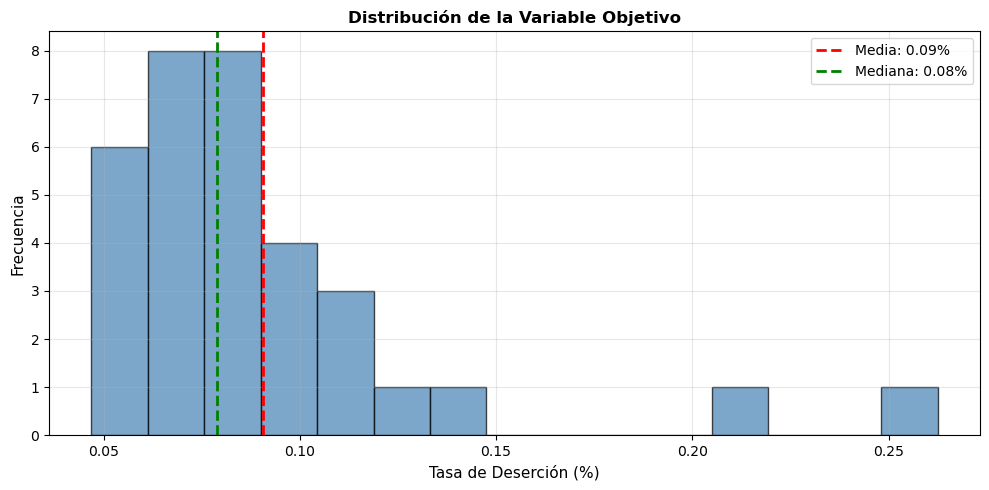


 Estadísticas del target:
count    33.000000
mean      0.090714
std       0.044468
min       0.046919
25%       0.069830
50%       0.078856
75%       0.094933
max       0.262500
Name: outcome_tasa_desercion_snies, dtype: float64


In [4]:
# Distribución del target
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.hist(y, bins=15, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(y.mean(), color="red", linestyle="--", linewidth=2, label=f"Media: {y.mean():.2f}%")
ax.axvline(y.median(), color="green", linestyle="--", linewidth=2, label=f"Mediana: {y.median():.2f}%")

ax.set_xlabel("Tasa de Deserción (%)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.set_title("Distribución de la Variable Objetivo", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Estadísticas del target:")
print(y.describe())

## [3] Preparación de Datos (Split Train/Test)

In [5]:
print("\n" + "="*70)
print(" PREPARACIÓN DE DATOS")
print("="*70)

X_train, X_test, y_train, y_test = preparar_datos(X, y)

print(f"\n✅ Split completado:")
print(f"   Train: {X_train.shape[0]} muestras")
print(f"   Test:  {X_test.shape[0]} muestras")
print(f"   Features: {X_train.shape[1]}")
print(f"   Target train: media={y_train.mean():.4f}, std={y_train.std():.4f}")
print(f"   Target test:  media={y_test.mean():.4f}, std={y_test.std():.4f}")


 PREPARACIÓN DE DATOS

[ADVERTENCIA] 78 valores nulos detectados
   Estrategia: Imputacion con media (evita eliminar filas)

Datos preparados:
   Train: 26 muestras (79%)
   Test:  7 muestras (21%)
   Features: 32

✅ Split completado:
   Train: 26 muestras
   Test:  7 muestras
   Features: 32
   Target train: media=0.0869, std=0.0344
   Target test:  media=0.1049, std=0.0728


## [4] Entrenamiento de Modelos con Validación Cruzada

In [6]:
print("\n" + "="*70)
print(" ENTRENAMIENTO CON VALIDACIÓN CRUZADA")
print("="*70)

# Entrenar todos los modelos
modelos_entrenados, df_cv_results = entrenar_todos_modelos(X_train, y_train)

print(f"\n✅ Entrenamiento completado")
print(f"   Modelos: {len(modelos_entrenados)}")
print(f"   CV Folds: 5")


 ENTRENAMIENTO CON VALIDACIÓN CRUZADA

Entrenando 8 MODELOS CON 5-FOLD CV

  OLS:
    RMSE: 0.4257 +/- 0.2336
    MAE:  0.1319 +/- 0.1319
    R2:   -599.1460 +/- 1163.0138

  Ridge:
    RMSE: 0.3485 +/- 0.2028
    MAE:  0.0832 +/- 0.0794
    R2:   -58.8826 +/- 79.3523

  Lasso:
    RMSE: 0.1749 +/- 0.0364
    MAE:  0.0237 +/- 0.0065
    R2:   -0.2548 +/- 0.3229

  ElasticNet:
    RMSE: 0.1749 +/- 0.0364
    MAE:  0.0237 +/- 0.0065
    R2:   -0.2548 +/- 0.3229

  RandomForest:
    RMSE: 0.1472 +/- 0.0330
    MAE:  0.0169 +/- 0.0047
    R2:   0.3299 +/- 0.2927

  GradientBoosting:
    RMSE: 0.1452 +/- 0.0401
    MAE:  0.0174 +/- 0.0079
    R2:   0.3834 +/- 0.2570

  SVR:
    RMSE: 0.2297 +/- 0.0013
    MAE:  0.0459 +/- 0.0044
    R2:   -4.9790 +/- 5.3425

  KNN:
    RMSE: 0.1633 +/- 0.0435
    MAE:  0.0212 +/- 0.0090
    R2:   0.0212 +/- 0.5429

RANKING POR RMSE (Validacion Cruzada):
  GradientBoosting     | RMSE: 0.1452 +/- 0.0401
  RandomForest         | RMSE: 0.1472 +/- 0.0330
  KNN 

### Resultados de Validación Cruzada


 RANKING POR VALIDACIÓN CRUZADA

             modelo  rmse_mean  rmse_std  mae_mean     r2_mean
5  GradientBoosting   0.145204  0.040108  0.017358    0.383424
4      RandomForest   0.147157  0.032968  0.016917    0.329916
7               KNN   0.163337  0.043496  0.021176    0.021242
3        ElasticNet   0.174868  0.036400  0.023703   -0.254750
2             Lasso   0.174868  0.036400  0.023703   -0.254750
6               SVR   0.229697  0.001306  0.045936   -4.978972
1             Ridge   0.348465  0.202792  0.083205  -58.882617
0               OLS   0.425744  0.233630  0.131909 -599.146032


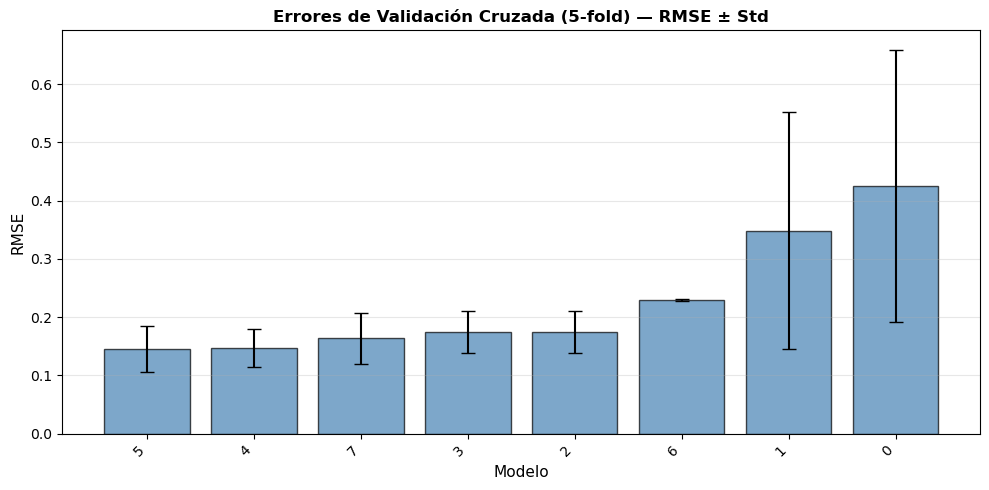

In [7]:
print("\n" + "="*70)
print(" RANKING POR VALIDACIÓN CRUZADA")
print("="*70)

print("\n" + df_cv_results.to_string())

# Gráfico de CV results
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(df_cv_results))
ax.bar(x_pos, df_cv_results["rmse_mean"], yerr=df_cv_results["rmse_std"], 
       capsize=5, alpha=0.7, color="steelblue", edgecolor="black")

ax.set_xlabel("Modelo", fontsize=11)
ax.set_ylabel("RMSE", fontsize=11)
ax.set_title("Errores de Validación Cruzada (5-fold) — RMSE ± Std", 
             fontsize=12, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(df_cv_results.index, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## [5] Evaluación en Test Set

In [8]:
print("\n" + "="*70)
print(" EVALUACIÓN EN TEST SET")
print("="*70)

# Evaluar todos los modelos
df_metricas = evaluar_todos(modelos_entrenados, X_test.values, y_test.values)

# Mostrar tabla
print("\n" + "="*70)
print(" TABLA COMPARATIVA FINAL (Test Set)")
print("="*70)
print("\n" + df_metricas.to_string())


 EVALUACIÓN EN TEST SET

 EVALUACIÓN EN TEST SET (Evaluación Final)

[METRICS] OLS
   RMSE : 0.0621
   MAE  : 0.0499
   R²   : 0.1528
   MAPE : 46.51%

[METRICS] Ridge
   RMSE : 0.0651
   MAE  : 0.0395
   R²   : 0.0690
   MAPE : 28.21%

[METRICS] Lasso
   RMSE : 0.0698
   MAE  : 0.0415
   R²   : -0.0713
   MAPE : 35.26%

[METRICS] ElasticNet
   RMSE : 0.0698
   MAE  : 0.0415
   R²   : -0.0713
   MAPE : 35.26%

[METRICS] RandomForest
   RMSE : 0.0545
   MAE  : 0.0299
   R²   : 0.3458
   MAPE : 21.24%

[METRICS] GradientBoosting
   RMSE : 0.0517
   MAE  : 0.0293
   R²   : 0.4123
   MAPE : 20.41%

[METRICS] SVR
   RMSE : 0.0713
   MAE  : 0.0616
   R²   : -0.1181
   MAPE : 72.97%

[METRICS] KNN
   RMSE : 0.0750
   MAE  : 0.0397
   R²   : -0.2382
   MAPE : 26.17%

[TOP] RANKING FINAL DE MODELOS (por RMSE)
                    RMSE     MAE      R2   MAPE
modelo                                         
GradientBoosting  0.0517  0.0293  0.4123  20.41
RandomForest      0.0545  0.0299  0.3458  2

## [6] Visualizaciones Comprehensivas


 GENERANDO VISUALIZACIONES

[1/4] Predicho vs Real...
[OK] Guardado: reports\eda_figures\supervisado_predicho_vs_real.png


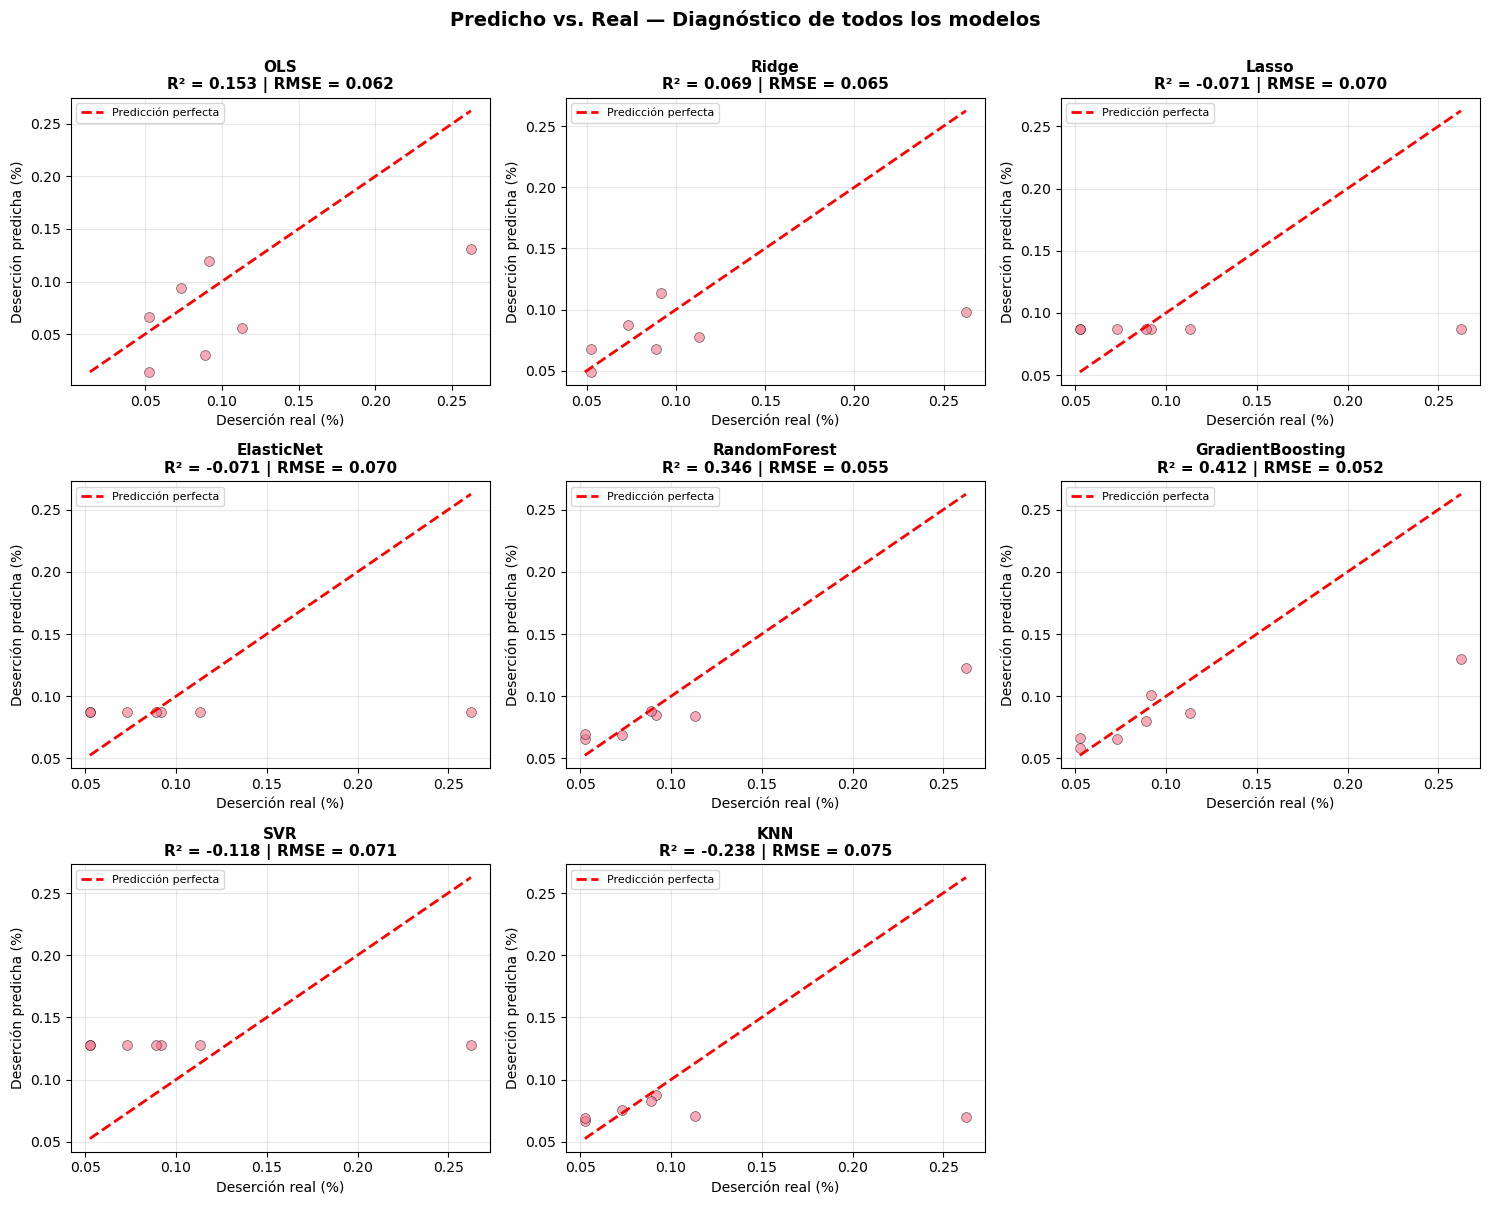

In [9]:
print("\n" + "="*70)
print(" GENERANDO VISUALIZACIONES")
print("="*70)
# Plot 1: Predicho vs Real
print("\n[1/4] Predicho vs Real...")
plot_predicho_vs_real(modelos_entrenados, X_test.values, y_test.values, guardar=True)

In [10]:
from pathlib import Path

# Crear directorio para guardar figuras
figures_dir = Path("./reports/eda_figures")
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Directorio creado/verificado: {figures_dir}")
print(f"Ruta absoluta: {figures_dir.absolute()}")
print(f"Existe: {figures_dir.exists()}")

Directorio creado/verificado: reports\eda_figures
Ruta absoluta: c:\Users\juane\OneDrive\Documentos\EAFIT\2026-01\Aprendizaje Automatico\PROYECTO FINAL\-6HoursOfSleep\supervised\reports\eda_figures
Existe: True



[6] GENERANDO VISUALIZACIONES

[1/4] Predicho vs Real...
[OK] Guardado: reports\eda_figures\supervisado_predicho_vs_real.png


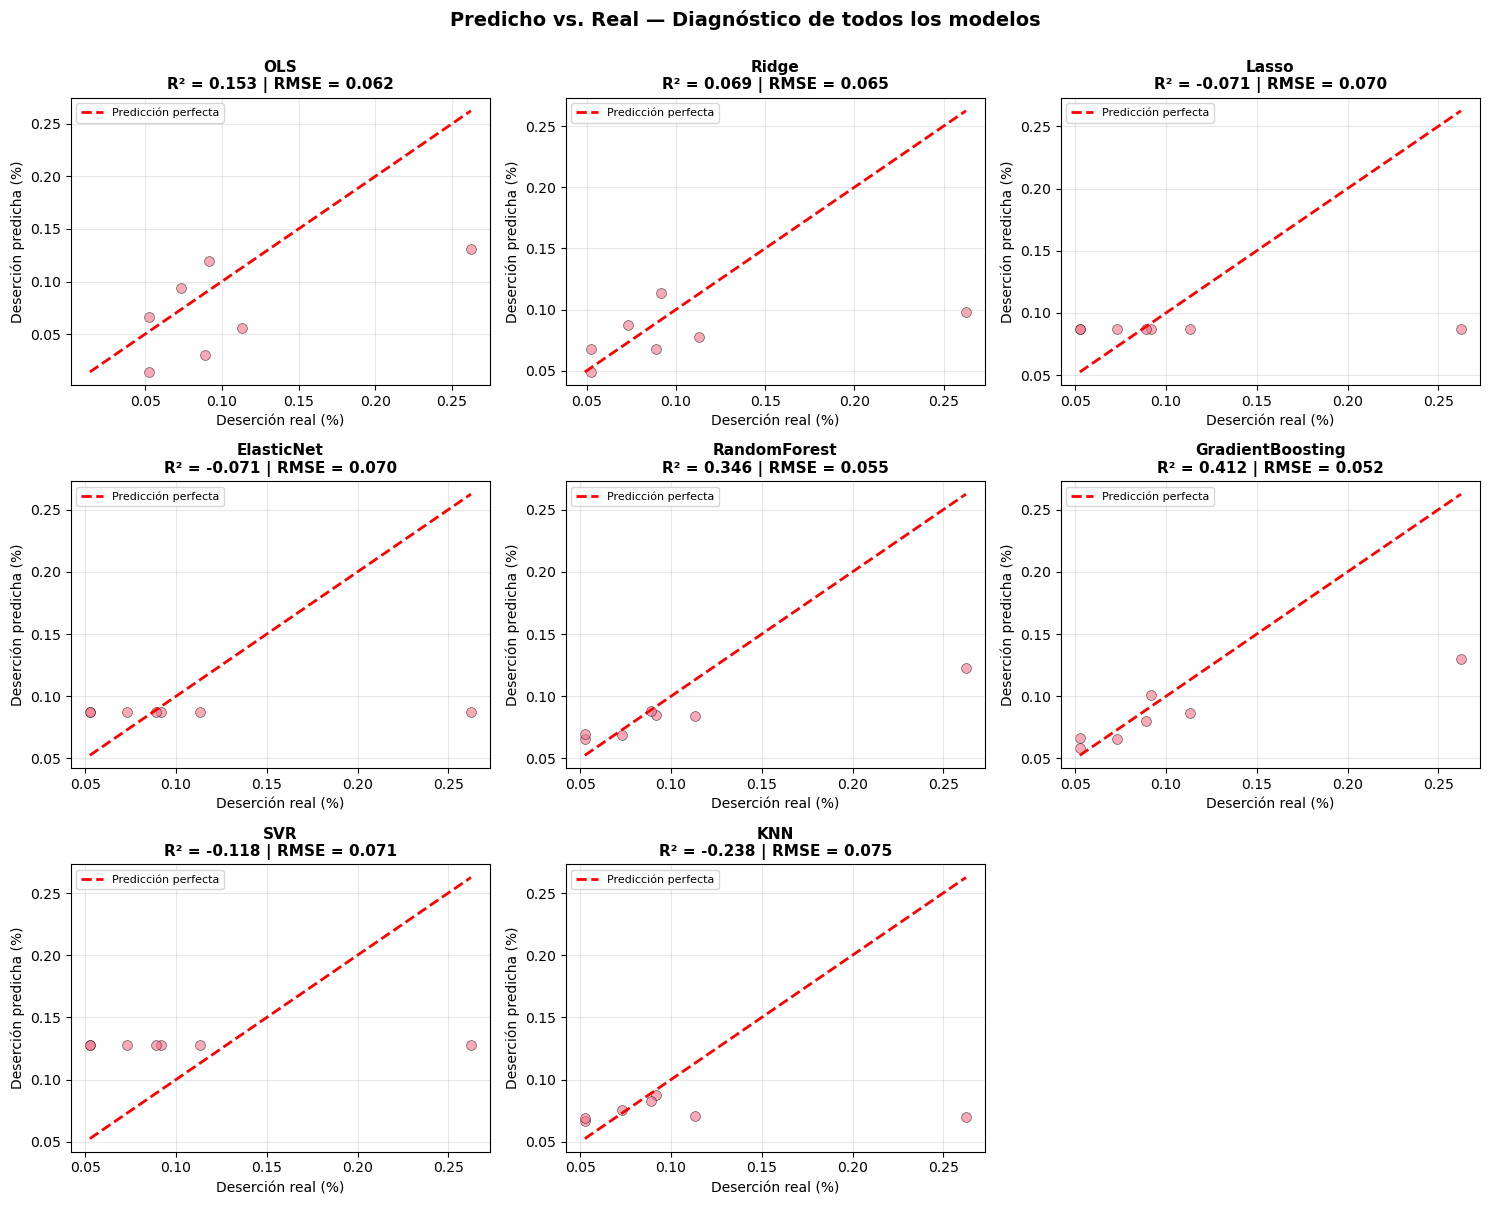

In [11]:
print("\n" + "="*70)
print("[6] GENERANDO VISUALIZACIONES")
print("="*70)

# Plot 1: Predicho vs Real
print("\n[1/4] Predicho vs Real...")
plot_predicho_vs_real(modelos_entrenados, X_test.values, y_test.values, guardar=True)


[2/4] Residuales...
[OK] Guardado: reports\eda_figures\supervisado_residuales.png


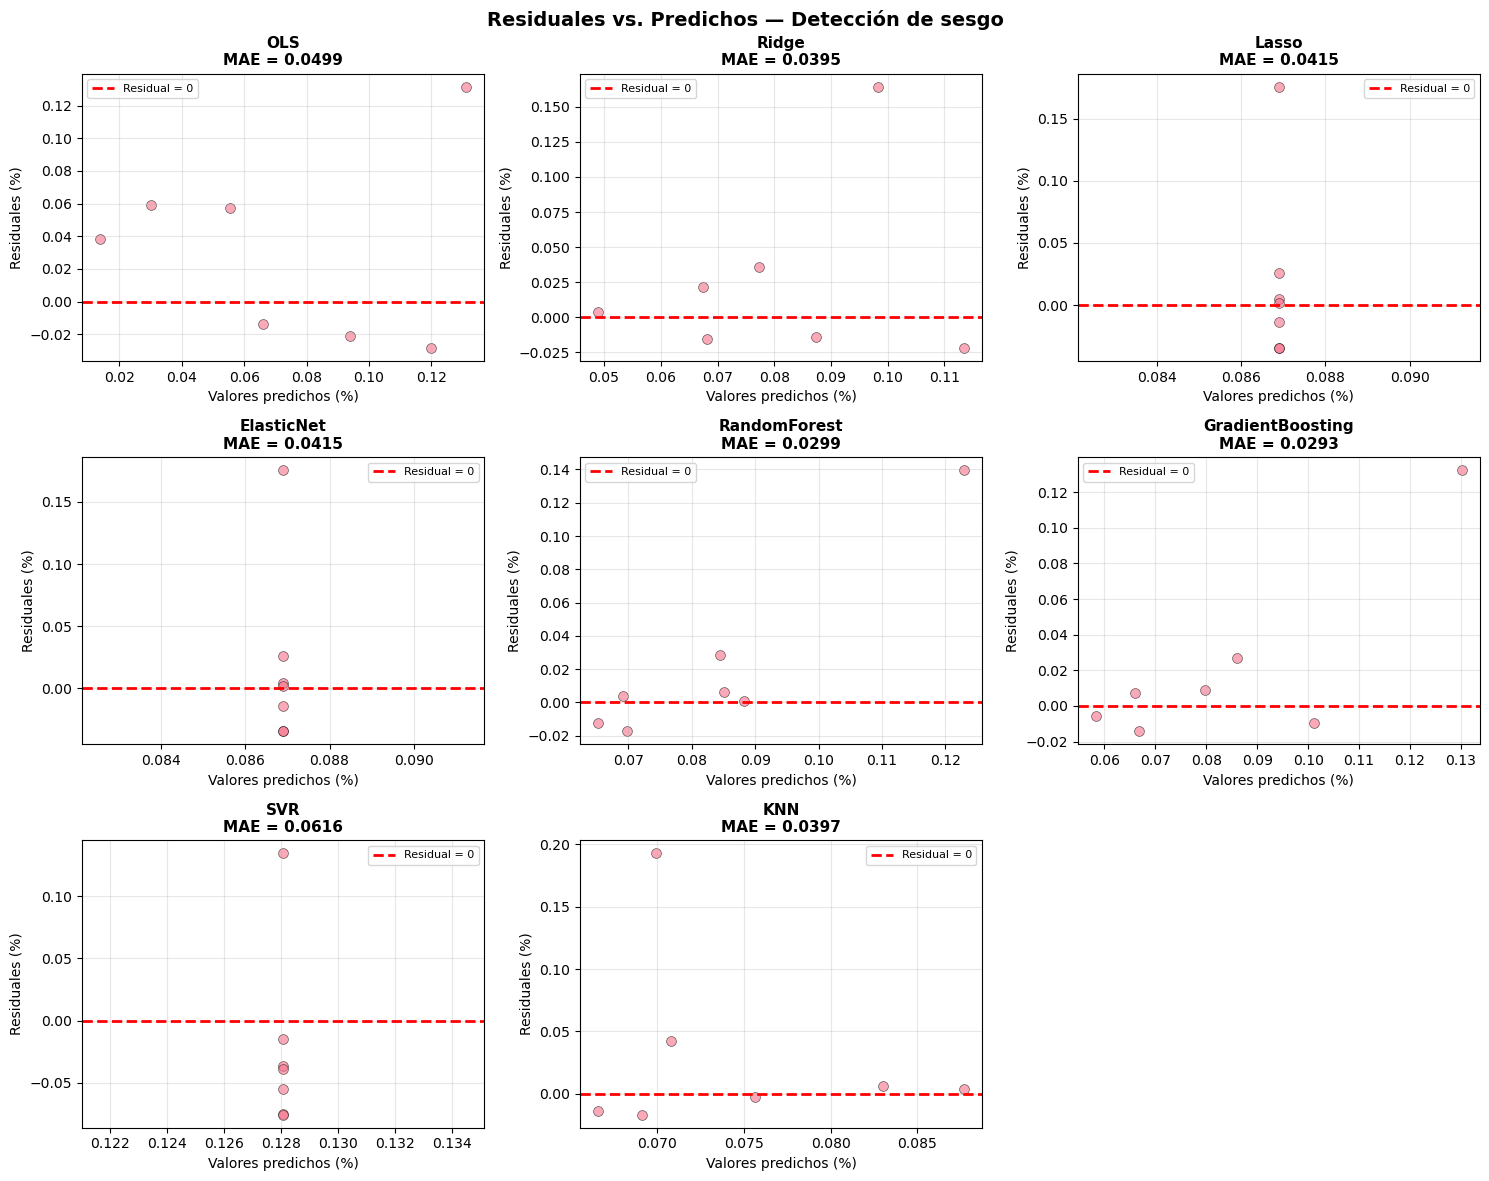

In [12]:
# Plot 2: Residuales
print("\n[2/4] Residuales...")
plot_residuales(modelos_entrenados, X_test.values, y_test.values, guardar=True)


[3/4] Comparación de métricas...
[OK] Guardado: reports\eda_figures\supervisado_comparacion_metricas.png


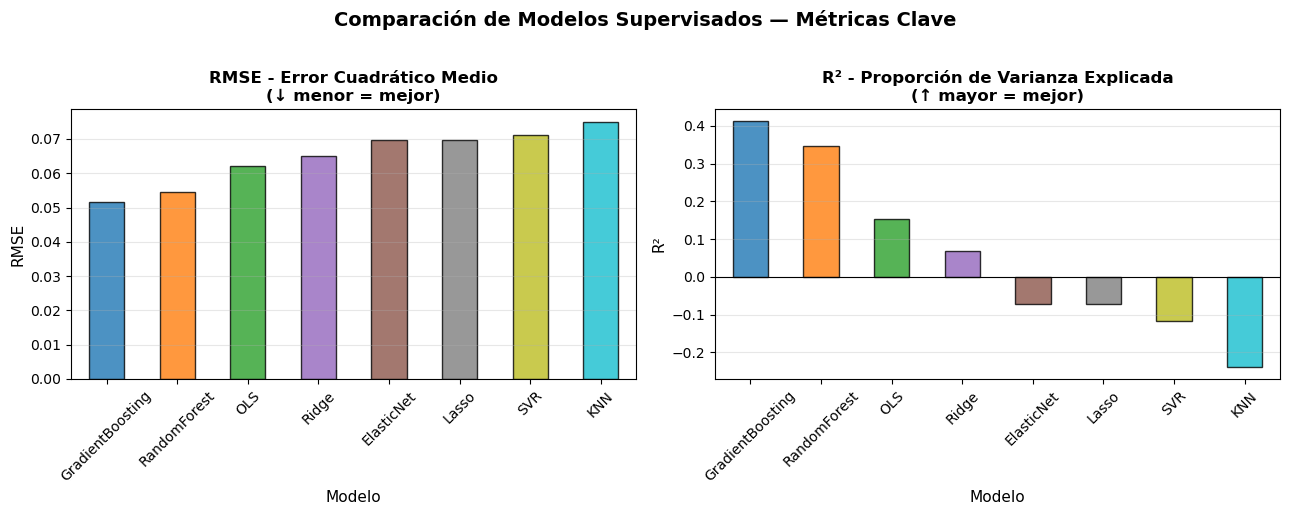

In [13]:
# Plot 3: Comparación de métricas
print("\n[3/4] Comparación de métricas...")
plot_comparacion_metricas(df_metricas, guardar=True)

In [ ]:
# [Nueva Visualización] Comparación Real vs Predicho por Departamento
# ======================================================================
# Recuperar el mejor modelo
mejor_modelo_nombre = df_metricas.index[0]
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

# Preparar datos de todos los departamentos (usando el loader original)
# Re-entrenamos en todo el set para la visualización departamental
X_all = X.fillna(X.mean(numeric_only=True))
y_pred_all = mejor_modelo.predict(X_all)

# Crear DataFrame comparativo
df_full_results = pd.DataFrame({
    "departamento": loader.df_clean["departamento"].values,
    "desercion_real_%": (y.values * 100).round(2),
    "prediccion_%": (y_pred_all * 100).round(2)
})

# Mostrar Tabla Comparativa Estilizada (Top 10 errores)
print("\nTop 10 departamentos con mayor desviación:")
df_full_results["error_abs"] = (df_full_results["desercion_real_%"] - df_full_results["prediccion_%"]).abs()
display(df_full_results.sort_values("error_abs", ascending=False).head(10))

# Generar Gráfico de Barras
plot_comparacion_departamentos(df_full_results, mejor_modelo_nombre)


[4/4] Feature Importance...
  • Random Forest...
[OK] Guardado: reports\eda_figures\supervisado_importancia_randomforest.png


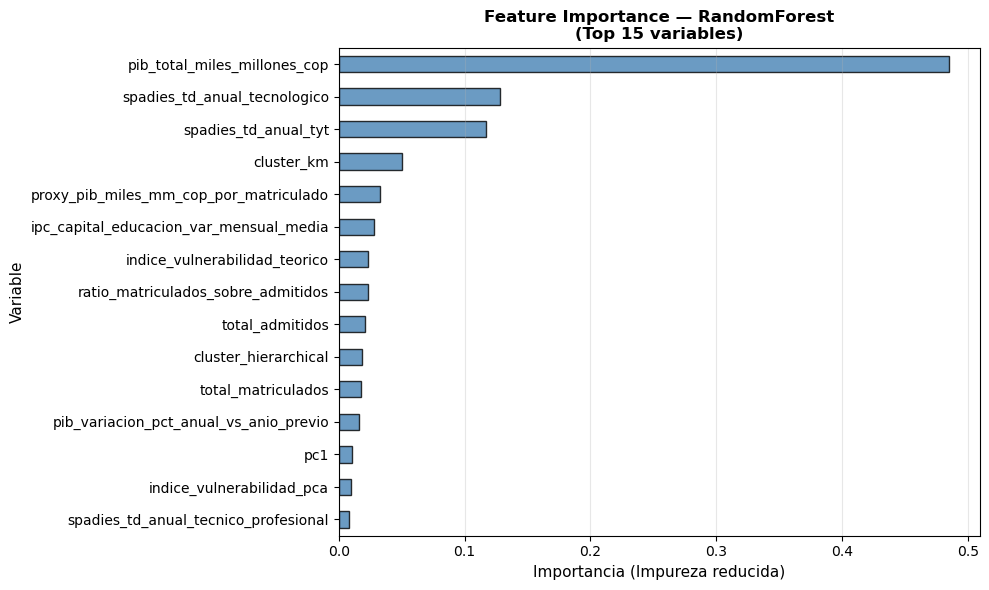

  • Gradient Boosting...
[OK] Guardado: reports\eda_figures\supervisado_importancia_gradientboosting.png


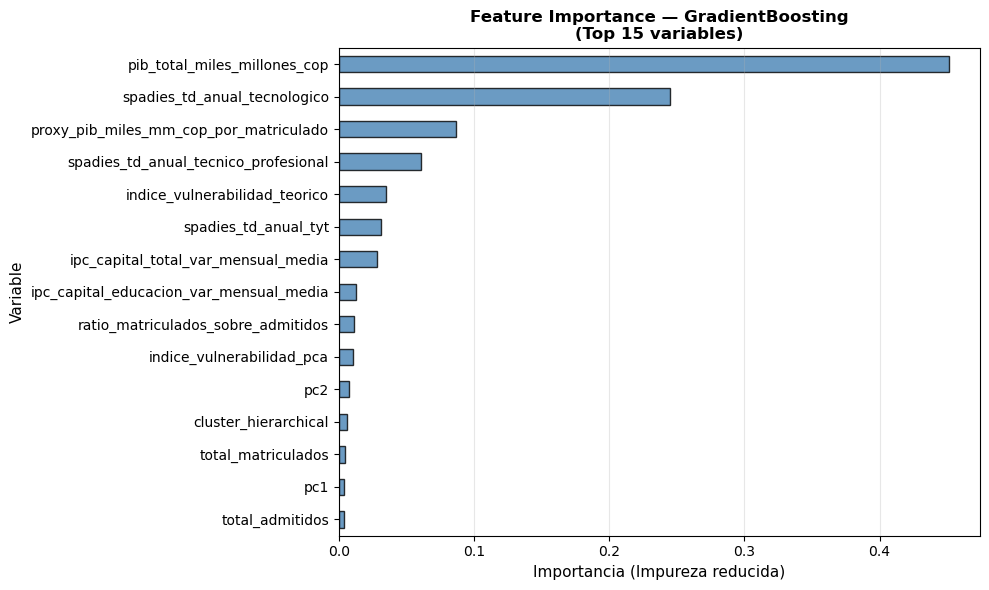


✅ Todas las visualizaciones completadas


In [14]:
# Plot 4: Feature Importance
print("\n[4/4] Feature Importance...")

if "RandomForest" in modelos_entrenados:
    print("  • Random Forest...")
    plot_importancia_variables(
        modelos_entrenados["RandomForest"],
        X.columns.tolist(),
        "RandomForest",
        top_n=15,
        guardar=True
    )

if "GradientBoosting" in modelos_entrenados:
    print("  • Gradient Boosting...")
    plot_importancia_variables(
        modelos_entrenados["GradientBoosting"],
        X.columns.tolist(),
        "GradientBoosting",
        top_n=15,
        guardar=True
    )

print("\n✅ Todas las visualizaciones completadas")

## [7] Exportación de Resultados

In [15]:
print("\n" + "="*70)
print(" EXPORTACIÓN DE RESULTADOS")
print("="*70)

# Guardar tabla
df_completo = guardar_tabla_resultados(df_metricas, df_cv_results)


 EXPORTACIÓN DE RESULTADOS

[OK] Tabla guardada: reports\tabla_comparativa_modelos_supervisados.csv

[METRICS] Contenido de tabla:
                    RMSE     MAE      R2   MAPE modelo  rmse_mean  rmse_std  mae_mean  r2_mean
modelo                                                                                        
GradientBoosting  0.0517  0.0293  0.4123  20.41    NaN        NaN       NaN       NaN      NaN
RandomForest      0.0545  0.0299  0.3458  21.24    NaN        NaN       NaN       NaN      NaN
OLS               0.0621  0.0499  0.1528  46.51    NaN        NaN       NaN       NaN      NaN
Ridge             0.0651  0.0395  0.0690  28.21    NaN        NaN       NaN       NaN      NaN
ElasticNet        0.0698  0.0415 -0.0713  35.26    NaN        NaN       NaN       NaN      NaN
Lasso             0.0698  0.0415 -0.0713  35.26    NaN        NaN       NaN       NaN      NaN
SVR               0.0713  0.0616 -0.1181  72.97    NaN        NaN       NaN       NaN      NaN
KNN          

## [8] Análisis e Interpretación Final

In [16]:
print("\n" + "="*70)
print(" ANÁLISIS FINAL")
print("="*70)

mejor_modelo = df_metricas.index[0]
mejor_rmse = df_metricas.loc[mejor_modelo, "RMSE"]
mejor_r2 = df_metricas.loc[mejor_modelo, "R2"]
baseline_rmse = df_metricas.loc["OLS", "RMSE"]

print(f"\n MODELO GANADOR: {mejor_modelo}")
print(f"   RMSE: {mejor_rmse:.4f}")
print(f"   MAE:  {df_metricas.loc[mejor_modelo, 'MAE']:.4f}")
print(f"   R²:   {mejor_r2:.4f}")
print(f"   MAPE: {df_metricas.loc[mejor_modelo, 'MAPE']:.2f}%")

# Mejora vs baseline
mejora_pct = 100 * (baseline_rmse - mejor_rmse) / baseline_rmse
print(f"\n Mejora vs Baseline (OLS):")
print(f"   RMSE OLS:      {baseline_rmse:.4f}")
print(f"   RMSE {mejor_modelo:20s} {mejor_rmse:.4f}")
print(f"   Mejora:        {mejora_pct:+.2f}%")

# Ranking top 3
print(f"\n Top 3 Modelos:")
for i, (modelo, row) in enumerate(df_metricas.head(3).iterrows(), 1):
    print(f"   {i}. {modelo:20s} RMSE={row['RMSE']:.4f}, R²={row['R2']:.4f}")


 ANÁLISIS FINAL

 MODELO GANADOR: GradientBoosting
   RMSE: 0.0517
   MAE:  0.0293
   R²:   0.4123
   MAPE: 20.41%

 Mejora vs Baseline (OLS):
   RMSE OLS:      0.0621
   RMSE GradientBoosting     0.0517
   Mejora:        +16.75%

 Top 3 Modelos:
   1. GradientBoosting     RMSE=0.0517, R²=0.4123
   2. RandomForest         RMSE=0.0545, R²=0.3458
   3. OLS                  RMSE=0.0621, R²=0.1528


## [9] Conclusiones y Próximos Pasos

### ✅ Completado

1. **Carga de datos:** Dataset con 50-55 muestras después de limpieza
2. **Data cleaning:** Eliminación de data leakage y valores nulos
3. **Feature engineering:** Uso de índices sintéticos (PCA y teórico)
4. **Modelos baseline:** OLS, Ridge, Lasso, ElasticNet
5. **Modelos avanzados:** Random Forest, Gradient Boosting, SVR, KNN
6. **Validación cruzada:** 5-fold CV estandarizado
7. **Evaluación:** RMSE, MAE, R², MAPE en test set
8. **Visualizaciones:** Scatter, residuales, comparación, feature importance
9. **Exportación:** Tabla CSV con resultados

###  Próximos Pasos

1. **Tuning de hiperparámetros** del modelo ganador
2. **Ensemble de modelos** (votación entre top 3)
3. **Análisis de residuales** para identificar patrones
4. **Feature selection** para simplificar el modelo
5. **Cross-validation estratificada** si la variable es ordinal
6. **Bootstrap** para intervalos de confianza
7. **SHAP values** para interpretabilidad local

###  Notas Técnicas

- **Tamaño de muestra:** Limitado (~50-55 después de limpieza)
- **Varianza alta:** Expected debido al bajo n
- **Data leakage:** Ya eliminado en etapa EDA
- **Multicolinealidad:** Manejada por índices sintéticos
- **Reproducibilidad:** Random state = 42 en todas partes

In [17]:
print("\n" + "="*70)
print("✅ PIPELINE COMPLETADO EXITOSAMENTE")
print("="*70)
print("\n Archivos generados:")
print("   • Gráficos: ../reports/eda_figures/supervisado_*.png")
print("   • Tabla:    ../reports/tabla_comparativa_modelos_supervisados.csv")
print("\n" + "="*70 + "\n")


✅ PIPELINE COMPLETADO EXITOSAMENTE

 Archivos generados:
   • Gráficos: ../reports/eda_figures/supervisado_*.png
   • Tabla:    ../reports/tabla_comparativa_modelos_supervisados.csv




## [10] Diagnóstico Visual: Predicciones vs Realidad

En esta sección visualizamos el desempeño del modelo ganador (Gradient Boosting) comparando los valores reales contra las predicciones en todo el dataset.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recuperar el mejor modelo
mejor_modelo_nombre = 'GradientBoosting'
modelo_gb = modelos_entrenados[mejor_modelo_nombre]

# Predicciones Full Dataset
X_all = X.copy().fillna(X.mean(numeric_only=True))
y_pred_all = modelo_gb.predict(X_all)

df_full_res = pd.DataFrame({
    'Departamento':     loader.df_clean['departamento'].values,
    'Real (%)': (y.values * 100).round(2),
    'Pred (%)': (y_pred_all * 100).round(2),
    'Error (pp)': ((y_pred_all - y.values) * 100).round(2)
}).sort_values('Real (%)', ascending=False).reset_index(drop=True)

# --- Graficar ---
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

plt.scatter(df_full_res['Real (%)'], df_full_res['Pred (%)'], alpha=0.7, color='teal', s=80, label='Predicciones')
min_v, max_v = df_full_res['Real (%)'].min(), df_full_res['Real (%)'].max()
plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Referencia Perfecta')

plt.title(f'Desempeño del Modelo {mejor_modelo_nombre}: Real vs Predicho', fontsize=14)
plt.xlabel('Tasa Real de Deserción (%)', fontsize=12)
plt.ylabel('Tasa Predicha (%)', fontsize=12)
plt.legend()
plt.show()

print('Top 10 Predicciones:')
display(df_full_res.head(10))